In [1]:
import kagglehub

path_fruits = kagglehub.dataset_download('moltean/fruits')
print('Dataset root:', path_fruits)

c:\Users\vasce\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resuming download from 3202351104 bytes (3233782215 bytes left)...
Resuming download to C:\Users\vasce\.cache\kagglehub\datasets\moltean\fruits\94.archive (3202351104/6436133319) bytes left.


100%|██████████| 5.99G/5.99G [01:18<00:00, 41.3MB/s]

Extracting files...


Dataset root: C:\Users\vasce\.cache\kagglehub\datasets\moltean\fruits\versions\94


In [101]:
import os
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import Callback, EarlyStopping

# Metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    classification_report
)

In [ ]:
# Build the specific paths to the training and test folders
train_dir = os.path.join(path_fruits, "fruits-360_100x100", "fruits-360", "Training")
test_dir = os.path.join(path_fruits, "fruits-360_100x100", "fruits-360", "Test")

print("---")
print("Train Directory:", train_dir)
print("Test Directory:", test_dir)

# Quick check to ensure the script sees them
if os.path.exists(train_dir) and os.path.exists(test_dir):
    print("\n Success! Folders found and separated.")
    print(f"Total training classes (fruits): {len(os.listdir(train_dir))}")
    print(f"Total test classes (fruits): {len(os.listdir(test_dir))}")
else:
    print("\n Paths built, but directories not found. Check the exact folder names inside:", os.listdir(os.path.join(path, "fruits-360_100x100")))

---
Train Directory: C:\Users\vasce\.cache\kagglehub\datasets\moltean\fruits\versions\94\fruits-360_100x100\fruits-360\Training
Test Directory: C:\Users\vasce\.cache\kagglehub\datasets\moltean\fruits\versions\94\fruits-360_100x100\fruits-360\Test

 Success! Folders found and separated.
Total training classes (fruits): 260
Total test classes (fruits): 260


In [ ]:
classes = sorted([c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))])
total_classes = len(classes)

print(f"Total number of classes detected: {total_classes}")

# CALCULATE CLASS DISTRIBUTION 
class_counts = {}
for c in classes:
    class_path = os.path.join(train_dir, c)
    class_counts[c] = len(os.listdir(class_path))

max_img = max(class_counts.values())
min_img = min(class_counts.values())
print(f"Class with the most images has: {max_img}")
print(f"Class with the fewest images has: {min_img}")
print(f"Are they completely balanced? {'Yes' if max_img == min_img else 'No, there is some variance.'}")

Total number of classes detected: 260
Class with the most images has: 984
Class with the fewest images has: 144
Are they completely balanced? No, there is some variance.


C:\Users\vasce\AppData\Local\Temp\ipykernel_32792\1147008287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=first_40_classes, y=first_40_counts, palette="viridis")


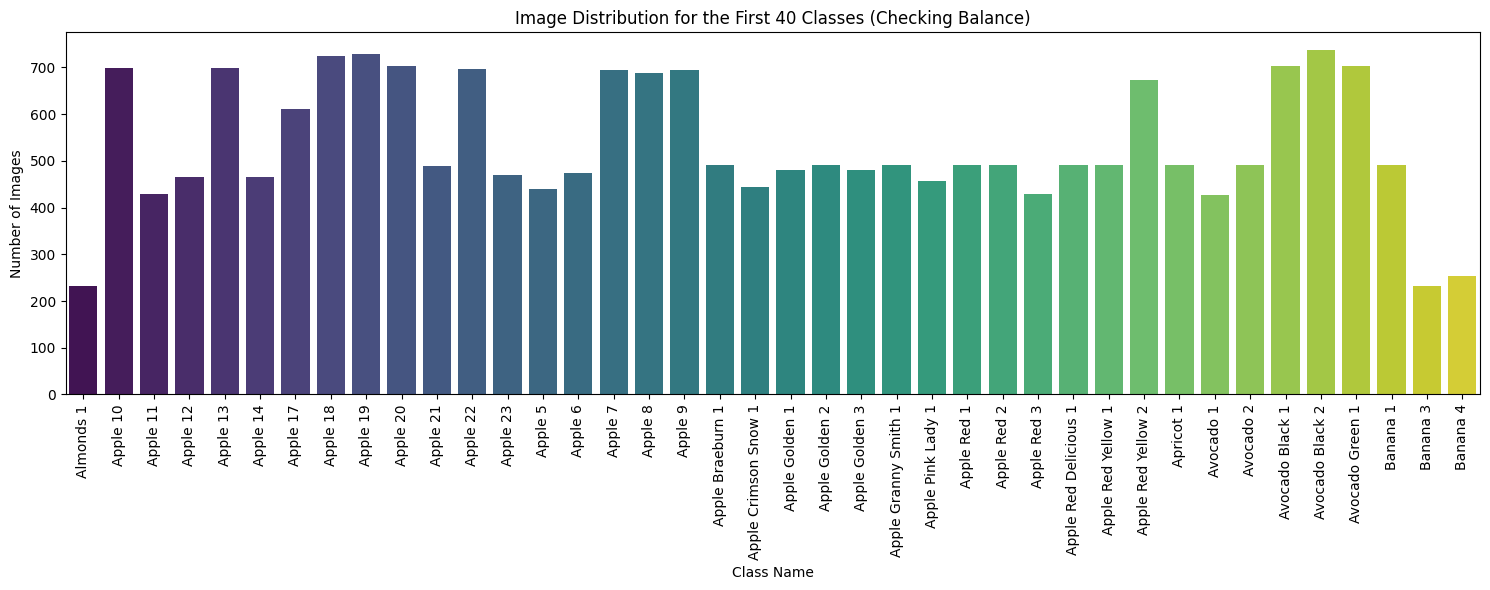

In [ ]:
# PLOT DISTRIBUTION (First 40 Classes)
first_40_classes = classes[:40]
first_40_counts = [class_counts[c] for c in first_40_classes]

plt.figure(figsize=(15, 6))
sns.barplot(x=first_40_classes, y=first_40_counts, palette="viridis")
plt.xticks(rotation=90)
plt.title("Image Distribution for the First 40 Classes (Checking Balance)")
plt.ylabel("Number of Images")
plt.xlabel("Class Name")
plt.tight_layout()
plt.show()

Sample Image Properties -> Format: JPEG | Size: (100, 100) | Mode: RGB


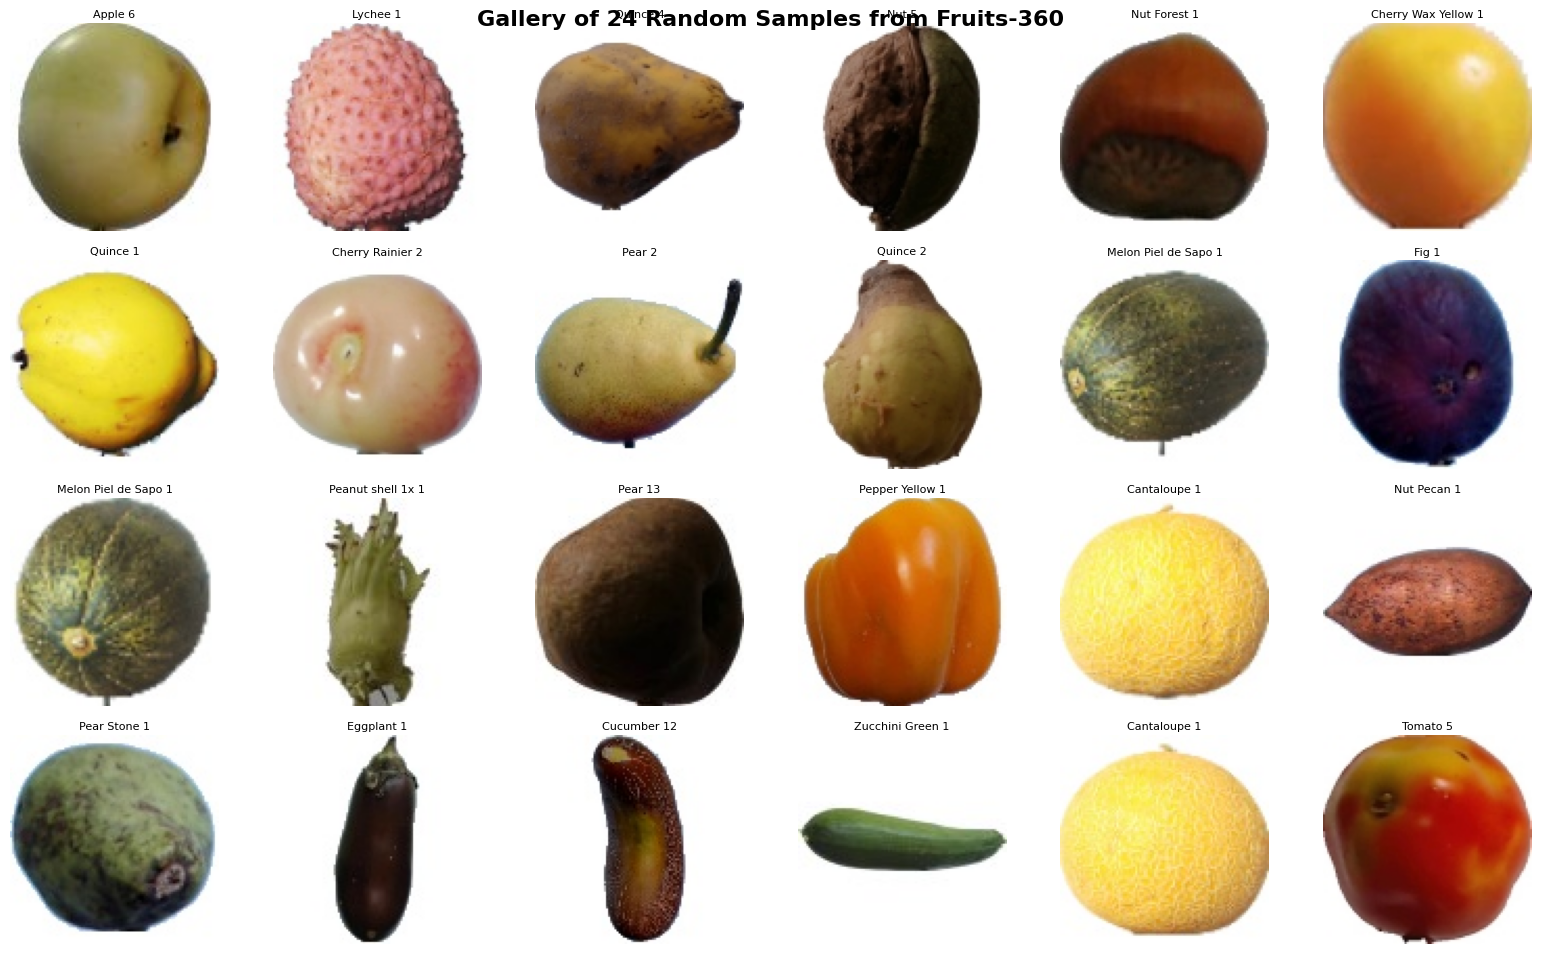

In [ ]:
ROWS = 4
COLS = 6
num_samples = ROWS * COLS

plt.figure(figsize=(16, 10))

for i in range(num_samples):
    # Pick a random class and a random image from that class
    random_class = random.choice(classes)
    class_path = os.path.join(train_dir, random_class)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)
    
    img = Image.open(img_path)
    
    if i == 0:
        print(f"Sample Image Properties -> Format: {img.format} | Size: {img.size} | Mode: {img.mode}")

    plt.subplot(ROWS, COLS, i + 1)
    plt.imshow(img)
    plt.title(random_class, fontsize=8, pad=4)
    plt.axis("off")

plt.suptitle(f"Gallery of {num_samples} Random Samples from Fruits-360", fontsize=16, weight='bold', y=0.95)
plt.tight_layout()
plt.show()

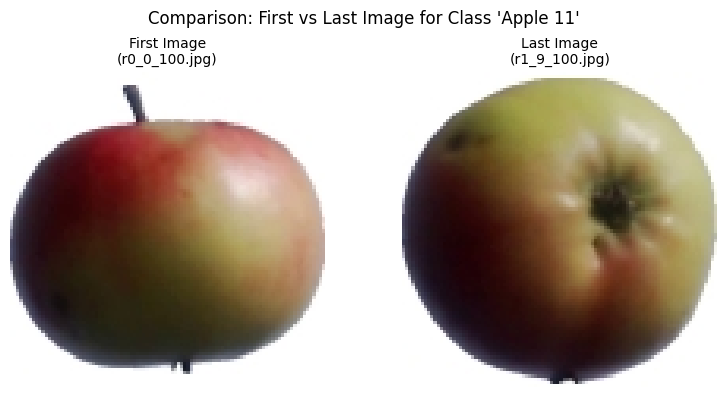

In [ ]:
#COMPARE FIRST AND LAST IMAGE OF A CLASS 
target_class = classes[2] 
class_path = os.path.join(train_dir, target_class)
all_images = sorted([img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])

if len(all_images) >= 2:
    first_img_path = os.path.join(class_path, all_images[0])
    last_img_path = os.path.join(class_path, all_images[-1])
    
    img_first = Image.open(first_img_path)
    img_last = Image.open(last_img_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_first)
    axes[0].set_title(f"First Image\n({all_images[0]})", fontsize=10)
    axes[0].axis("off")
    
    axes[1].imshow(img_last)
    axes[1].set_title(f"Last Image\n({all_images[-1]})", fontsize=10)
    axes[1].axis("off")
    
    plt.suptitle(f"Comparison: First vs Last Image for Class '{target_class}'", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough images in class '{target_class}' to perform first/last comparison.")

In [ ]:

# Load Train and Validation Sets (Handles 80/20 split, resize, and shuffle)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,                  # Seed ensures train/val sets don't overlap
    image_size=(48, 48),      # Resizes images to 48x48
    batch_size=32,
    shuffle=True              # Shuffles the training data
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,                  # Must match training seed!
    image_size=(48, 48),
    batch_size=32,
    shuffle=True              # Shuffles validation data as well
)

# Rescale images from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("\nTensorFlow datasets are ready!")

Found 137221 files belonging to 260 classes.
Using 109777 files for training.
Found 137221 files belonging to 260 classes.
Using 27444 files for validation.

TensorFlow datasets are ready!


In [ ]:


# Define transforms (Resize and Rescale to [0,1])
preprocessing_transforms = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor() # Converts PIL Image to tensor and automatically rescales to [0.0, 1.0]
])

full_dataset = datasets.ImageFolder(root=train_dir, transform=preprocessing_transforms)

# Perform 80/20 train/validation split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# random_split inherently shuffles which index goes to which set
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

print(f"PyTorch DataLoaders ready!")
print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

PyTorch DataLoaders ready!
Training samples: 109776 | Validation samples: 27445


Metric                    | TensorFlow                | PyTorch                  
--------------------------------------------------------------------------------
Batch Tensor Shape        | [32, 48, 48, 3]           | [32, 3, 48, 48]          
Data Type (Dtype)         | <dtype: 'float32'>        | torch.float32            
Minimum Pixel Value       | 0.0000                    | 0.0000                   
Maximum Pixel Value       | 1.0000                    | 1.0000                   


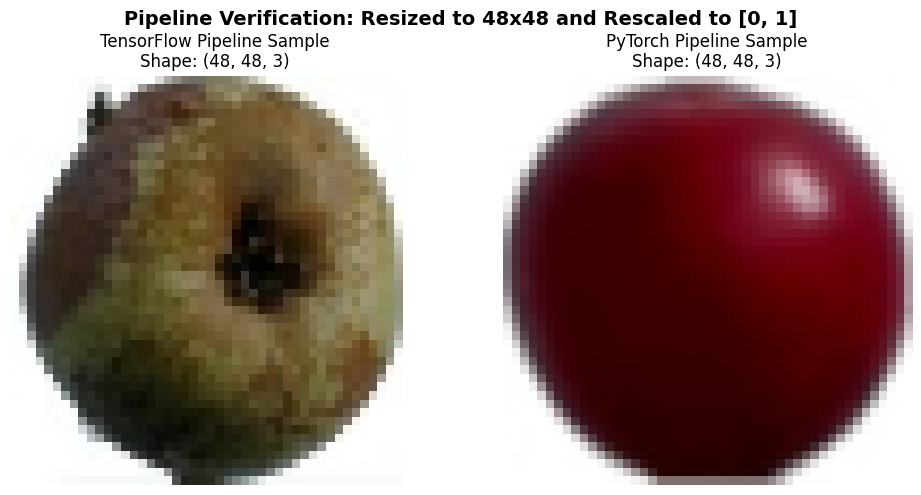

In [ ]:
import torch
# EXTRACT BATCH FROM TENSORFLOW
for tf_images, tf_labels in train_ds.take(1):
    tf_batch_shape = tf_images.shape
    tf_min_val = tf.reduce_min(tf_images).numpy()
    tf_max_val = tf.reduce_max(tf_images).numpy()
    tf_dtype = tf_images.dtype
    # Grab the first image array from this batch
    single_tf_img = tf_images[0].numpy() 
    break

#2. EXTRACT BATCH FROM PYTORCH
for pt_images, pt_labels in train_loader:
    pt_batch_shape = pt_images.shape
    pt_min_val = torch.min(pt_images).item()
    pt_max_val = torch.max(pt_images).item()
    pt_dtype = pt_images.dtype
    single_pt_img = pt_images[0].permute(1, 2, 0).numpy()
    break

# PRINT STRUCTURAL METRICS COMPARISON
print(f"{'Metric':<25} | {'TensorFlow':<25} | {'PyTorch':<25}")
print("-" * 80)
print(f"{'Batch Tensor Shape':<25} | {str(list(tf_batch_shape)):<25} | {str(list(pt_batch_shape)):<25}")
print(f"{'Data Type (Dtype)':<25} | {str(tf_dtype):<25} | {str(pt_dtype):<25}")
print(f"{'Minimum Pixel Value':<25} | {tf_min_val:<25.4f} | {pt_min_val:<25.4f}")
print(f"{'Maximum Pixel Value':<25} | {tf_max_val:<25.4f} | {pt_max_val:<25.4f}")

# 4. VISUAL RENDER COMPARISON 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(single_tf_img)
axes[0].set_title(f"TensorFlow Pipeline Sample\nShape: {single_tf_img.shape}")
axes[0].axis('off')

axes[1].imshow(single_pt_img)
axes[1].set_title(f"PyTorch Pipeline Sample\nShape: {single_pt_img.shape}")
axes[1].axis('off')

plt.suptitle("Pipeline Verification: Resized to 48x48 and Rescaled to [0, 1]", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:


# CUSTOM TIMING CALLBACK 
class EpochTimer(Callback):
    """Custom callback to measure and print the duration of each epoch."""
    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()
        
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.start_time
        print(f" - Epoch time: {duration:.2f} seconds")



In [ ]:
# 2. CNN CONFIGURATOR
def build_cnn(
    num_classes,
    filters=(32, 64, 128),
    kernel_size=3,
    strides=1,
    padding='same',
    pool='max',
    dropout_rate=0.0,
    l2_reg=0.0,
    input_shape=(48, 48, 3), 
    augment_pipeline=None 
):
    """Configurable CNN builder for systematic experiments."""
    pool_layer = layers.MaxPooling2D if pool == 'max' else layers.AveragePooling2D
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    model = keras.Sequential(name='CNN')
    model.add(layers.Input(shape=input_shape))
    
    for f in filters:
        model.add(layers.Conv2D(f, kernel_size, strides=strides,
                                padding=padding, activation='relu',
                                kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(pool_layer(2))
        
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=reg))
    
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
        
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model



In [ ]:
# TRAINING ENGINE

def train_model(model, train_ds, val_ds, epochs=15, callbacks=None,
                verbose=1, early_stop=True, patience=3):
    """Compile, fit, and return history. Adds EarlyStopping unless one is already passed."""
    cbs = list(callbacks) if callbacks else []
    
    if early_stop and not any(isinstance(c, EarlyStopping) for c in cbs):
        cbs.append(EarlyStopping(monitor='val_accuracy', patience=patience,
                                 restore_best_weights=True, verbose=1))
    cbs.append(EpochTimer()) 
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cbs,
        verbose=verbose
    )
    return history

In [ ]:


# Look directly inside the training folder to count the actual class directories
detected_classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]
num_detected_classes = len(detected_classes)

print(f"Dynamically detected {num_detected_classes} classes in directory.")

baseline_model = build_cnn(
    num_classes=num_detected_classes,        
    filters=(32, 64, 128),  
    input_shape=(48, 48, 3) 
)

history_baseline = train_model(
    model=baseline_model,   
    train_ds=train_ds, 
    val_ds=val_ds, 
    epochs=10
)

Dynamically detected 260 classes in your directory.
Epoch 1/10
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7226 - loss: 1.1982 - Epoch time: 138.69 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 139s 40ms/step - accuracy: 0.8789 - loss: 0.4554 - val_accuracy: 0.9330 - val_loss: 0.2103
Epoch 2/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9651 - loss: 0.1161 - Epoch time: 88.51 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 89s 26ms/step - accuracy: 0.9714 - loss: 0.0955 - val_accuracy: 0.9811 - val_loss: 0.0615
Epoch 3/10
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9793 - loss: 0.0729 - Epoch time: 89.07 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 89s 26ms/step - accuracy: 0.9812 - loss: 0.0673 - val_accuracy: 0.9684 - val_loss: 0.1182
Epoch 4/10
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9879 - loss: 0.0449 - Epoch time: 90.64 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 91s 26ms/step - accuracy: 0.9884 - loss: 0.0424 - val_accuracy: 0.9820 - val_loss: 0

In [40]:
baseline_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,021,710 (15.34 MB)

 Trainable params: 1,340,420 (5.11 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,680,842 (10.23 MB)

In [ ]:


#Configuration Constants
SEED = 42
EXPERIMENT_EPOCHS = 5  # 10 epochs per test is a great sweet spot but 5 is better for testing
results = []

# Systematic architecture configurations
experiments = [
    dict(name='Baseline',           filters=(32,64,128), strides=1, padding='same', pool='max'),
    dict(name='Fewer filters',      filters=(16,32,64),  strides=1, padding='same', pool='max'),
    dict(name='AvgPool',            filters=(32,64,128), strides=1, padding='same', pool='avg'),
    dict(name='Stride=2 (no pool)', filters=(32,64,128), strides=2, padding='same', pool='none') 
]


# Execution Loop
for i, exp_orig in enumerate(experiments, 1):
    exp = exp_orig.copy()
    name = exp.pop('name')
    
    print(f'\n>>> [{i}/{len(experiments)}] Training: {name}', flush=True)
    tf.random.set_seed(SEED)
    
    if exp['pool'] == 'none':
        exp['pool'] = 'max'
        exp['filters'] = (32, 64) 
    
    m = build_cnn(num_classes=num_detected_classes, input_shape=(48, 48, 3), **exp)
    h = train_model(m, train_ds, val_ds, epochs=EXPERIMENT_EPOCHS, verbose=0)
    
    # Extract results
    best_val = max(h.history['val_accuracy'])
    results.append({
        'Experiment': name,
        'Filters': str(exp_orig['filters']), # Keeping original description for the table
        'Strides': exp_orig['strides'],
        'Padding': exp_orig['padding'],
        'Pool': exp_orig['pool'],
        'Val Accuracy': round(best_val, 4)
    })
    print(f'   >>> [{name}] best_val_acc={best_val:.4f}', flush=True)

# Display Results Table sorted by best performance
results_df = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Architecture Experiments ===')
print(results_df.to_string(index=False))


>>> [1/4] Training: Baseline
 - Epoch time: 92.59 seconds
 - Epoch time: 89.07 seconds
 - Epoch time: 88.29 seconds
 - Epoch time: 88.91 seconds
 - Epoch time: 96.40 seconds
 - Epoch time: 93.67 seconds
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
   >>> [Baseline] best_val_acc=0.9893

>>> [2/4] Training: Fewer filters
 - Epoch time: 51.29 seconds
 - Epoch time: 52.64 seconds
 - Epoch time: 52.12 seconds
 - Epoch time: 52.51 seconds
 - Epoch time: 52.38 seconds
 - Epoch time: 58.08 seconds
 - Epoch time: 55.11 seconds
 - Epoch time: 54.81 seconds
 - Epoch time: 56.16 seconds
 - Epoch time: 55.23 seconds
Restoring model weights from the end of the best epoch: 9.
   >>> [Fewer filters] best_val_acc=0.9952

>>> [3/4] Training: AvgPool
 - Epoch time: 93.18 seconds
 - Epoch time: 89.14 seconds
 - Epoch time: 92.62 seconds
 - Epoch time: 91.84 seconds
 - Epoch time: 94.53 seconds
 - Epoch time: 94.07 seconds
 - Epoch time: 94.90 seconds
 - Epoch time: 9

In [ ]:
# Ensure directory for figures exists
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Extract configurations dynamically from the top row of the results DataFrame
best_filters = tuple(ast.literal_eval(results_df.iloc[0]['Filters']))
best_padding = str(results_df.iloc[0]['Padding'])
best_pool    = str(results_df.iloc[0]['Pool'])
best_strides = int(results_df.iloc[0]['Strides'])

print(f"Rebuilding best architecture configuration discovered:")
print(f" -> Filters: {best_filters} | Strides: {best_strides} | Padding: {best_padding} | Pool: {best_pool}\n")

# Rebuild model with regularizations AND the corrected 48x48 shape
tf.random.set_seed(SEED)

best_cnn = build_cnn(
    num_classes=num_detected_classes,  
    filters=best_filters,
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.4,                 
    l2_reg=1e-4,                       
    input_shape=(48, 48, 3)            
)

best_cnn.summary()

# Generate network diagram cleanly via plot_model
_arch_path = FIGURES_DIR / 'cnn_03_architecture.png'
try:
    keras.utils.plot_model(
        best_cnn,
        to_file=str(_arch_path),
        show_shapes=True,
        show_layer_names=True,
        dpi=120                          # Slightly higher DPI for sharper resolution in notebooks
    )
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=str(_arch_path)))
    print("Success! Corrected 48x48 diagram rendered above.")
    
except (ImportError, OSError, TypeError) as e:
    print(f'plot_model visualization error ({e}). Falling back to text summary above.')

Rebuilding best architecture configuration discovered:
 -> Filters: (32, 64, 128) | Strides: 2 | Padding: same | Pool: none



Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 24, 24, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_21            │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_22            │ (None, 3, 3, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_23            │ (None, 1, 1, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,988 (757.77 KB)

 Trainable params: 193,540 (756.02 KB)

 Non-trainable params: 448 (1.75 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
plot_model visualization error ([Errno 2] No such file or directory: 'figures\\cnn_03_architecture.png'). Falling back to text summary above.


In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_accuracy', patience=2, factor=0.5, verbose=1)

best_history = train_model(best_cnn, train_ds, val_ds, epochs=6, callbacks=[es, rlr])
print(f'Best model val accuracy: {max(best_history.history["val_accuracy"]):.4f}')

Epoch 1/6
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5770 - loss: 1.7121 - Epoch time: 38.46 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.7690 - loss: 0.8590 - val_accuracy: 0.8752 - val_loss: 0.4240 - learning_rate: 0.0010
Epoch 2/6
3425/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9337 - loss: 0.2713 - Epoch time: 36.82 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.9417 - loss: 0.2509 - val_accuracy: 0.9598 - val_loss: 0.2046 - learning_rate: 0.0010
Epoch 3/6
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9546 - loss: 0.2233 - Epoch time: 36.12 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.9577 - loss: 0.2166 - val_accuracy: 0.9787 - val_loss: 0.1577 - learning_rate: 0.0010
Epoch 4/6
3426/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9651 - loss: 0.2022 - Epoch time: 38.47 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9660 - loss: 0.2010 - val_accuracy: 0.9603 - 

>>> Training Model WITHOUT Data Augmentation...
Epoch 1/5
3423/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5660 - loss: 1.7447 - Epoch time: 35.10 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.7623 - loss: 0.8798 - val_accuracy: 0.9222 - val_loss: 0.2876
Epoch 2/5
3424/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9290 - loss: 0.2829 - Epoch time: 34.94 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.9382 - loss: 0.2613 - val_accuracy: 0.9304 - val_loss: 0.2708
Epoch 3/5
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9506 - loss: 0.2336 - Epoch time: 34.35 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.9556 - loss: 0.2218 - val_accuracy: 0.9765 - val_loss: 0.1600
Epoch 4/5
3423/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9640 - loss: 0.2048 - Epoch time: 34.95 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.9652 - loss: 0.2026 - val_accuracy: 0.9730 - val_loss: 0.1734
Epoch 5/

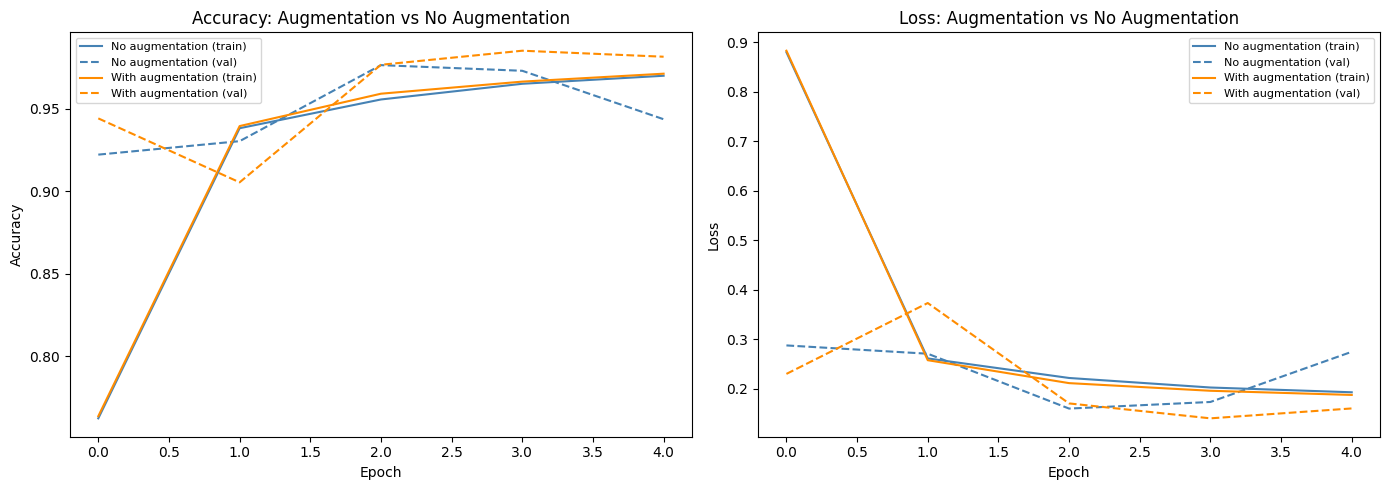

In [ ]:


# Define the Augmentation Pipeline (Stays exactly the same)
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),       
    layers.RandomZoom(0.1),           
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomBrightness(0.1),
], name='augmentation')

# Train Model WITHOUT Data Augmentation 
print(">>> Training Model WITHOUT Data Augmentation...", flush=True)
tf.random.set_seed(SEED)
m_no_aug = build_cnn(
    num_classes=num_detected_classes, 
    filters=best_filters, 
    strides=best_strides,
    padding=best_padding, 
    pool=best_pool, 
    dropout_rate=0.4, 
    l2_reg=1e-4,
    input_shape=(48, 48, 3),
    augment_pipeline=None 
)
hist_no_aug = train_model(m_no_aug, train_ds, val_ds, epochs=5)

# Train Model WITH Data Augmentation
print("\n>>> Training Model WITH Data Augmentation...", flush=True)
tf.random.set_seed(SEED)
m_aug = build_cnn(
    num_classes=num_detected_classes, 
    filters=best_filters, 
    strides=best_strides,
    padding=best_padding, 
    pool=best_pool, 
    dropout_rate=0.4, 
    l2_reg=1e-4,
    input_shape=(48, 48, 3),
    augment_pipeline=augmentation # Safely injected here!
)
# Notice we pass the clean, unmapped train_ds here now!
hist_aug = train_model(m_aug, train_ds, val_ds, epochs=5)

# Generate and Overlay Learning Curves
print('\n=== Final Comparison Summary ===')
print('No-aug val acc:', max(hist_no_aug.history['val_accuracy']))
print('With-aug val acc:', max(hist_aug.history['val_accuracy']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for hist, label, color in [
    (hist_no_aug, 'No augmentation', 'steelblue'),
    (hist_aug,    'With augmentation', 'darkorange')
]:
    ax1.plot(hist.history['accuracy'],     linestyle='-',  color=color, label=f'{label} (train)')
    ax1.plot(hist.history['val_accuracy'], linestyle='--', color=color, label=f'{label} (val)')
    ax2.plot(hist.history['loss'],         linestyle='-',  color=color, label=f'{label} (train)')
    ax2.plot(hist.history['val_loss'],     linestyle='--', color=color, label=f'{label} (val)')

ax1.set_title('Accuracy: Augmentation vs No Augmentation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(fontsize=8)
ax2.set_title('Loss: Augmentation vs No Augmentation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_04_augmentation_comparison.png', dpi=150)
plt.show()

In [ ]:


# Deliberately Overfit: Massive model capacity, no regularization, no early stopping
print(">>> Training OVERFIT Model (Massive capacity, completely unconstrained)...", flush=True)
tf.random.set_seed(SEED)

m_overfit = build_cnn(
    num_classes=num_detected_classes, 
    filters=(128, 256, 512),         
    strides=best_strides,           
    padding=best_padding, 
    pool=best_pool,
    dropout_rate=0.0,                
    l2_reg=0.0,                     
    input_shape=(48, 48, 3),
    augment_pipeline=None            
)

hist_overfit = train_model(
    m_overfit, 
    train_ds,                       
    val_ds, 
    epochs=6, 
    early_stop=False                 
)


# Regularized Version: Same massive capacity, safely guarded inline
print("\n>>> Training REGULARIZED Model (Same capacity, but guarded)...", flush=True)
tf.random.set_seed(SEED)

m_reg = build_cnn(
    num_classes=num_detected_classes, 
    filters=(128, 256, 512),
    strides=best_strides, 
    padding=best_padding, 
    pool=best_pool,
    dropout_rate=0.5,                
    l2_reg=1e-3,                     
    input_shape=(48, 48, 3),
    augment_pipeline=augmentation    
)

es_reg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

hist_reg = train_model(
    m_reg, 
    train_ds,                       
    val_ds, 
    epochs=6, 
    callbacks=[es_reg]
)

# Print out the head-to-head performance metrics
print('\n=== Overfitting Demonstration Results ===')
print(f"Overfit model  - best val acc: {max(hist_overfit.history['val_accuracy']):.4f}")
print(f"Regularised    - best val acc: {max(hist_reg.history['val_accuracy']):.4f}")

>>> Training OVERFIT Model (Massive capacity, completely unconstrained)...
Epoch 1/6
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7039 - loss: 1.1589 - Epoch time: 90.14 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 90s 26ms/step - accuracy: 0.8604 - loss: 0.4831 - val_accuracy: 0.9038 - val_loss: 0.3154
Epoch 2/6
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9606 - loss: 0.1165 - Epoch time: 89.33 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 89s 26ms/step - accuracy: 0.9659 - loss: 0.1010 - val_accuracy: 0.8826 - val_loss: 0.4436
Epoch 3/6
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9783 - loss: 0.0661 - Epoch time: 89.07 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 89s 26ms/step - accuracy: 0.9796 - loss: 0.0616 - val_accuracy: 0.9772 - val_loss: 0.0743
Epoch 4/6
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9840 - loss: 0.0492 - Epoch time: 89.55 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 90s 26ms/step - accuracy: 0.9844 - loss: 0.0486 - val_accuracy: 0.9

In [ ]:


print(">>> Loading pre-trained ResNet50V2 (48x48 native layout)...", flush=True)

# Instantiate ResNet50V2 to accept 48x48 images natively (skips slow upscaling)
resnet_fast_base = keras.applications.ResNet50V2(
    weights='imagenet',       
    include_top=False,        
    input_shape=(48, 48, 3)   
)
resnet_fast_base.trainable = False

#Build the structural sequence with proper color adjustment
m_resnet_fast = keras.Sequential([
    layers.Input(shape=(48, 48, 3)),
    
    layers.Lambda(lambda x: x * 255.0, name="resnet_denormalize"),
    
    layers.Lambda(keras.applications.resnet_v2.preprocess_input, name="resnet_preprocess"),
    
    resnet_fast_base,
    layers.GlobalAveragePooling2D(),  
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),              
    layers.Dense(num_detected_classes, activation='softmax')
], name='ResNet50V2_Fast_Transfer')

m_resnet_fast.summary()

print("\n=== Training Fast ResNet50V2 ===")
tf.random.set_seed(SEED)

hist_resnet = train_model(m_resnet_fast, train_ds, val_ds, epochs=5)
print(f"\nResNet50V2 - Best Val Acc: {max(hist_resnet.history['val_accuracy']):.4f}")

>>> Loading pre-trained ResNet50V2 (48x48 native layout)...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50V2_Fast_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet_denormalize (Lambda)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 2, 2, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,156,164 (92.15 MB)

 Trainable params: 591,364 (2.26 MB)

 Non-trainable params: 23,564,800 (89.89 MB)


=== Training Fast ResNet50V2 ===
Epoch 1/2
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4368 - loss: 2.5224 - Epoch time: 210.83 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 211s 61ms/step - accuracy: 0.5960 - loss: 1.5496 - val_accuracy: 0.8866 - val_loss: 0.3512
Epoch 2/2
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7654 - loss: 0.7526 - Epoch time: 209.39 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 209s 61ms/step - accuracy: 0.7817 - loss: 0.7004 - val_accuracy: 0.9248 - val_loss: 0.2208
Restoring model weights from the end of the best epoch: 2.

ResNet50V2 - Best Val Acc: 0.9248


In [ ]:


print(">>> Configuring pre-trained MobileNetV2 for small images...", flush=True)

#Instantiate MobileNetV2 with a safe, optimized spatial resolution (96x96)
mobilenet_base = keras.applications.MobileNetV2(
    weights='imagenet',       
    include_top=False,        
    input_shape=(96, 96, 3)   # Scale up to 96x96 to protect the internal feature blocks
)
mobilenet_base.trainable = False

# Build the sequential wrapper with an upscaling and denormalization stage
m_mobilenet = keras.Sequential([
    layers.Input(shape=(48, 48, 3)), 
    
    layers.Resizing(96, 96, interpolation='bilinear', name="mobilenet_upscale"),
    
    layers.Lambda(lambda x: x * 255.0, name="mobilenet_denormalize"),
    
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input, name="mobilenet_preprocess"),
    
    mobilenet_base,
    layers.GlobalAveragePooling2D(),  
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),              
    layers.Dense(num_detected_classes, activation='softmax')
], name='MobileNetV2_Transfer')

m_mobilenet.summary()

print("\n=== Training MobileNetV2 Feature Extractor ===")
tf.random.set_seed(SEED)

hist_mobilenet = train_model(m_mobilenet, train_ds, val_ds, epochs=5)
print(f"\nMobileNetV2 - Best Val Acc: {max(hist_mobilenet.history['val_accuracy']):.4f}")

>>> Configuring pre-trained MobileNetV2 for small images...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_upscale (Resizing)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_denormalize (Lambda)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,740 (10.12 MB)

 Trainable params: 394,756 (1.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


=== Training MobileNetV2 Feature Extractor ===
Epoch 1/5
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6730 - loss: 1.4067 - Epoch time: 172.84 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 173s 50ms/step - accuracy: 0.8384 - loss: 0.6070 - val_accuracy: 0.9825 - val_loss: 0.0560
Epoch 2/5
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9486 - loss: 0.1507 - Epoch time: 184.07 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 184s 54ms/step - accuracy: 0.9531 - loss: 0.1360 - val_accuracy: 0.9877 - val_loss: 0.0332
Epoch 3/5
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9633 - loss: 0.1062 - Epoch time: 179.02 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 179s 52ms/step - accuracy: 0.9641 - loss: 0.1038 - val_accuracy: 0.9927 - val_loss: 0.0200
Epoch 4/5
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9688 - loss: 0.0904 - Epoch time: 180.75 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 181s 53ms/step - accuracy: 0.9697 - loss: 0.0888 - val_accuracy: 0.9948 - val_loss: 0.0

=== Model Architecture Comparison ===
     Model Name  Best Val Accuracy                 Type
    MobileNetV2             0.9950    Transfer Learning
Your Custom CNN             0.9765 Scratch Architecture
       ResNet50             0.9248    Transfer Learning


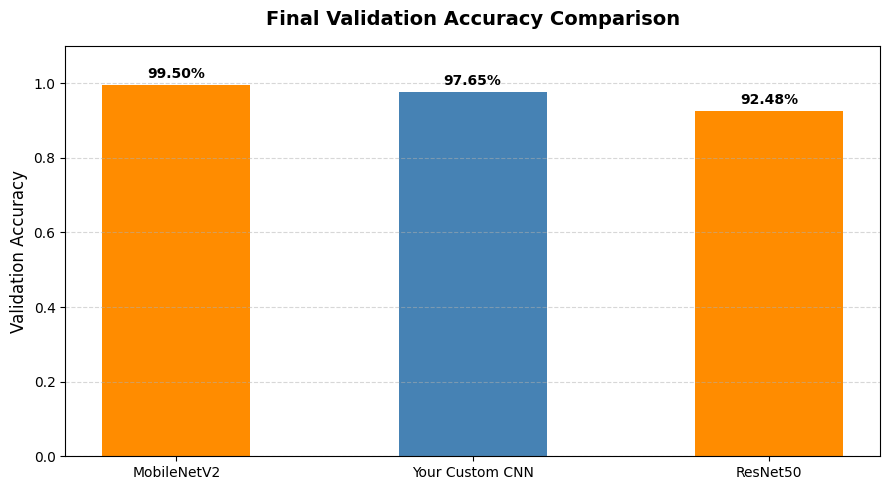

In [ ]:
# Gather the best validation scores from each history tracker
try:
    custom_acc = max(hist_no_aug.history['val_accuracy'])
except NameError:
    custom_acc = max(history_baseline.history['val_accuracy'])

resnet_acc = max(hist_resnet.history['val_accuracy'])
mobilenet_acc = max(hist_mobilenet.history['val_accuracy'])

#Organize the statistics into a comparison DataFrame
comparison_data = [
    {"Model Name": " Custom CNN", "Best Val Accuracy": round(custom_acc, 4), "Type": "Scratch Architecture"},
    {"Model Name": "ResNet50", "Best Val Accuracy": round(resnet_acc, 4), "Type": "Transfer Learning"},
    {"Model Name": "MobileNetV2", "Best Val Accuracy": round(mobilenet_acc, 4), "Type": "Transfer Learning"}
]

comparison_df = pd.DataFrame(comparison_data).sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)

print("=== Model Architecture Comparison ===")
print(comparison_df.to_string(index=False))
print("=" * 37)

# Plot a polished bar chart comparison
plt.figure(figsize=(9, 5))
colors = ['darkorange' if t == 'Transfer Learning' else 'steelblue' for t in comparison_df['Type']]

bars = plt.bar(comparison_df['Model Name'], comparison_df['Best Val Accuracy'], color=colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval*100:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Final Validation Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save the visualization to the existing figures folder
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_05_final_comparison.png', dpi=150)
plt.show()

In [ ]:


# Setup destination path
MODELS_DIR = Path("saved_models")
MODELS_DIR.mkdir(exist_ok=True)
model_save_path = MODELS_DIR / "best_fruits360_model.keras"

#Select the top performing architecture to be the final model
final_model = best_cnn 

# Save and confirm
print(f">>> Exporting champion network model to: {model_save_path}...", flush=True)
final_model.save(model_save_path)

print("\n=== Active Final Model Architecture Configured ===")
final_model.summary()

>>> Exporting champion network model to: saved_models\best_fruits360_model.keras...

=== Active Final Model Architecture Configured ===


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 24, 24, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_21            │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_22            │ (None, 3, 3, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_23            │ (None, 1, 1, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581,070 (2.22 MB)

 Trainable params: 193,540 (756.02 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 387,082 (1.48 MB)

In [ ]:


print(">>> Assigning the champion model to final_model...")

try:
    custom_acc = max(hist_no_aug.history['val_accuracy'])
    best_model_var = m_no_aug
except NameError:
    custom_acc = max(history_baseline.history['val_accuracy'])
    best_model_var = m_baseline

resnet_acc = max(hist_resnet.history['val_accuracy'])
mobilenet_acc = max(hist_mobilenet.history['val_accuracy'])

if custom_acc >= resnet_acc and custom_acc >= mobilenet_acc:
    final_model = best_model_var
elif resnet_acc >= custom_acc and resnet_acc >= mobilenet_acc:
    final_model = m_resnet
else:
    final_model = m_mobilenet

IMG_SIZE = final_model.input_shape[1:3]  
BATCH_SIZE = 32

print(f">>> Building final test evaluation dataset at size {IMG_SIZE}...")
raw_test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

# FIX: Extract class names from the raw BatchDataset object BEFORE mapping
class_names = raw_test_ds.class_names

final_test_ds = raw_test_ds.map(lambda x, y: (x / 255.0, y))

# Collect all predictions on the normalized test set
y_true, y_pred_probs = [], []
for x_batch, y_batch in final_test_ds:
    probs = final_model.predict(x_batch, verbose=0)
    y_pred_probs.append(probs)
    y_true.extend(y_batch.numpy())

y_pred_probs = np.vstack(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)

print(f'Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Macro Precision: {prec:.4f}')
print(f'Macro Recall   : {rec:.4f}')
print()
print('Target: accuracy > 80%, precision & recall > 70%')
print(f'  Accuracy OK : {acc > 0.80}')
print(f'  Precision OK: {prec > 0.70}')
print(f'  Recall OK   : {rec > 0.70}')

>>> Assigning the champion model to final_model...
>>> Building final test evaluation dataset at size (48, 48)...
Found 45724 files belonging to 260 classes.
Test Accuracy : 0.9571 (95.71%)
Macro Precision: 0.9590
Macro Recall   : 0.9546

Target: accuracy > 80%, precision & recall > 70%
  Accuracy OK : True
  Precision OK: True
  Recall OK   : True


C:\Users\vasce\AppData\Local\Temp\ipykernel_32792\3511779175.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_df, x='Errors', y='Class', palette='rocket')


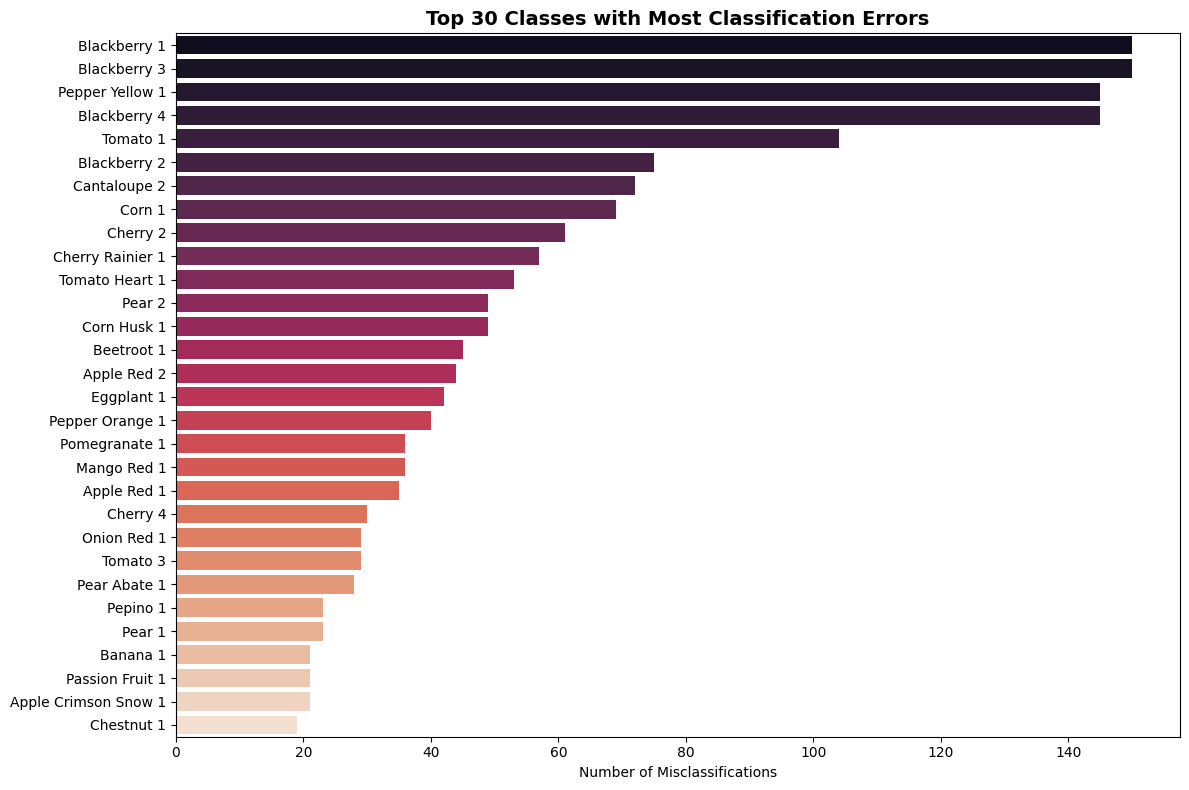

In [ ]:
# Calculate how many times each class was misclassified
# Get the diagonal of the confusion matrix (correct predictions)
correct_preds = np.diag(cm)
total_per_class = cm.sum(axis=1)
errors_per_class = total_per_class - correct_preds

# Plot the 30 classes with the highest error counts
error_df = pd.DataFrame({'Class': class_names, 'Errors': errors_per_class}).sort_values(by='Errors', ascending=False).head(30)

plt.figure(figsize=(12, 8))
sns.barplot(data=error_df, x='Errors', y='Class', palette='rocket')
plt.title('Top 30 Classes with Most Classification Errors', fontsize=14, fontweight='bold')
plt.xlabel('Number of Misclassifications')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_06_error_distribution.png', dpi=150)
plt.show()

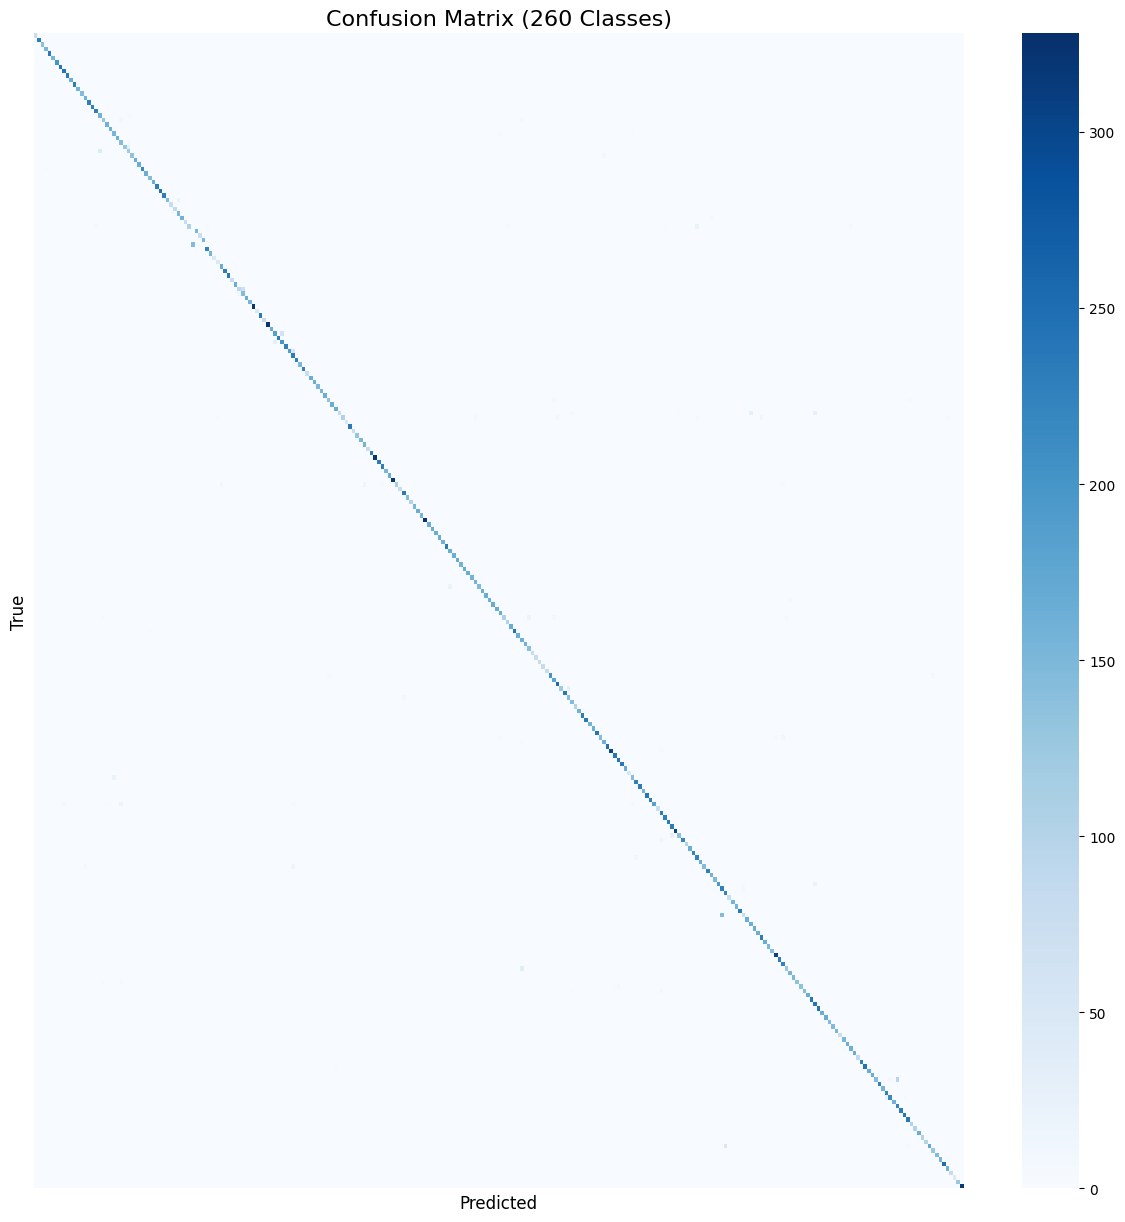

In [ ]:
# Create a cleaner version without grid lines
plt.figure(figsize=(15, 15))
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False, linewidths=0, cbar=True)

plt.title('Confusion Matrix (260 Classes)', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)

plt.savefig(FIGURES_DIR / 'cnn_06_confusion_matrix_clean.png', dpi=300)
plt.show()

Ten hardest classes (lowest F1):
                 precision    recall  f1-score  support
Blackberry 1      0.000000  0.000000  0.000000    150.0
Blackberry 2      0.000000  0.000000  0.000000     75.0
Blackberry 3      0.000000  0.000000  0.000000    150.0
Blackberry 4      0.000000  0.000000  0.000000    145.0
Pepper Yellow 1   0.885057  0.346847  0.498382    222.0
Cantaloupe 2      0.893204  0.560976  0.689139    164.0
Corn 1            1.000000  0.540000  0.701299    150.0
Apple Red 2       0.727273  0.731707  0.729483    164.0
Tomato 1          1.000000  0.577236  0.731959    246.0
Pepper Orange 2   0.603723  0.965957  0.743044    235.0


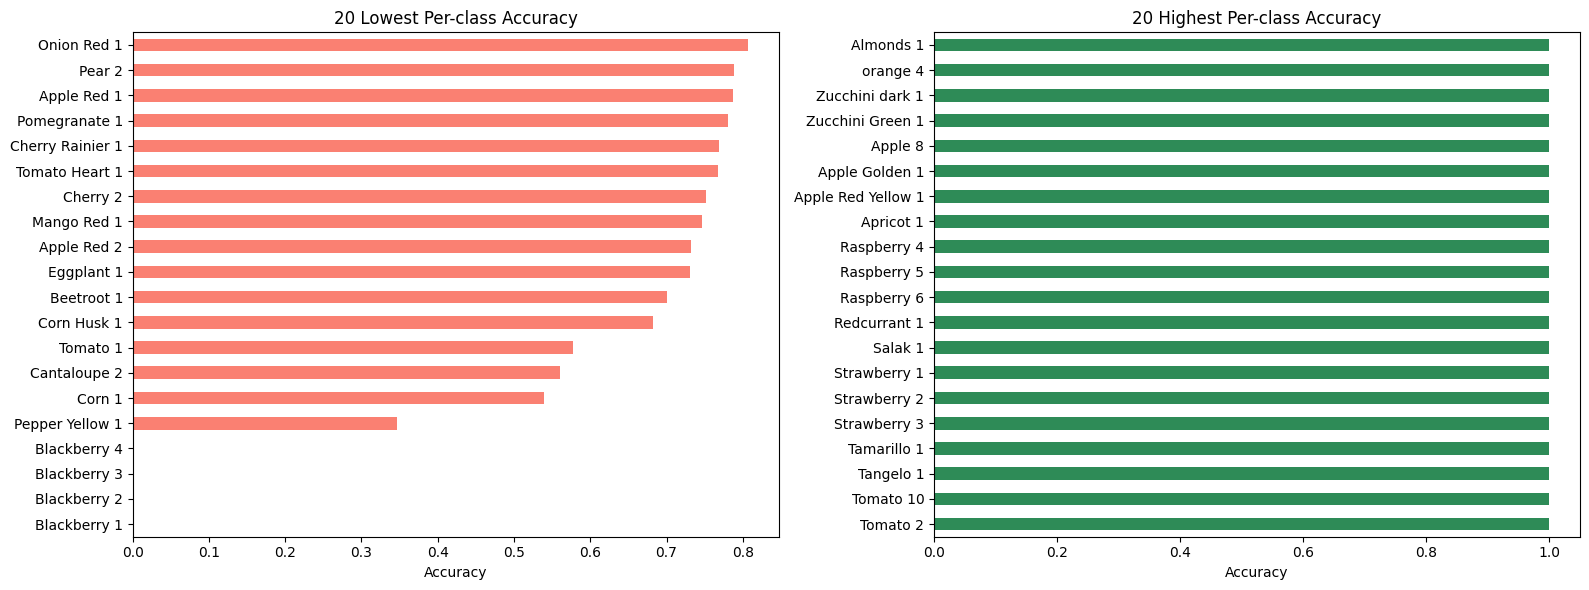

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names,
                               output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
per_class_df = per_class_df[['precision', 'recall', 'f1-score', 'support']].sort_values('f1-score')

# Show bottom-10 hardest classes
print('Ten hardest classes (lowest F1):')
print(per_class_df.head(10).to_string())

per_cls_acc = {cls: (cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0)
               for i, cls in enumerate(class_names)}
acc_series = pd.Series(per_cls_acc).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
acc_series.head(20).plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('20 Lowest Per-class Accuracy')
axes[0].set_xlabel('Accuracy')
acc_series.tail(20).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('20 Highest Per-class Accuracy')
axes[1].set_xlabel('Accuracy')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_07_per_class_accuracy.png', dpi=150)
plt.show()

Found 45724 files belonging to 260 classes.


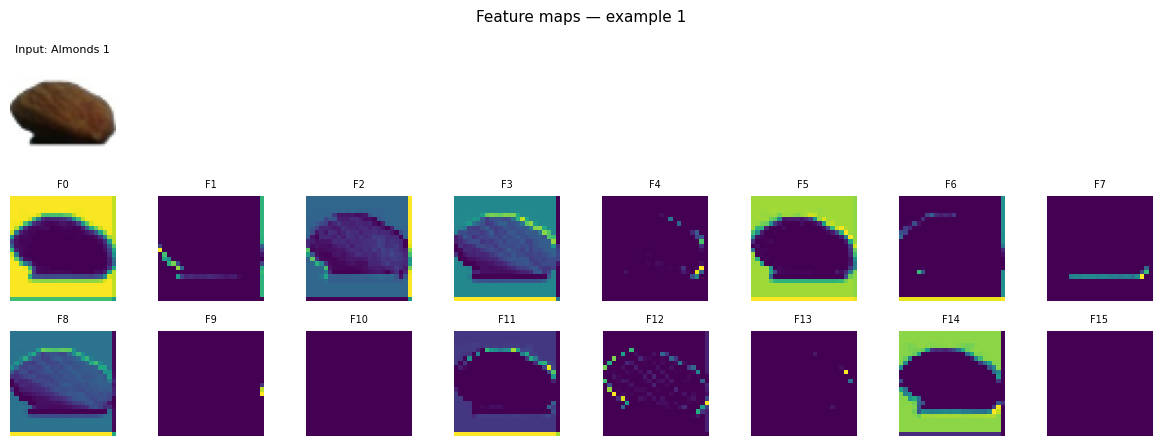

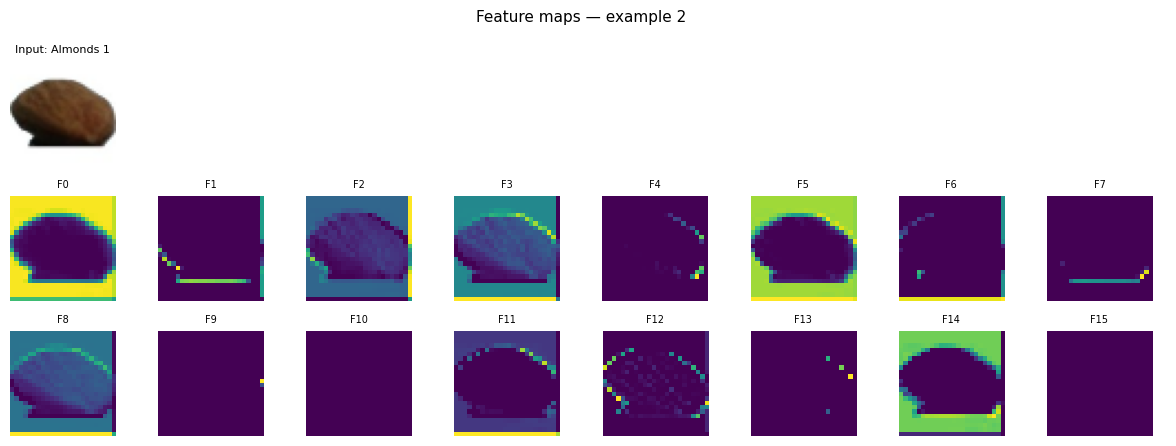

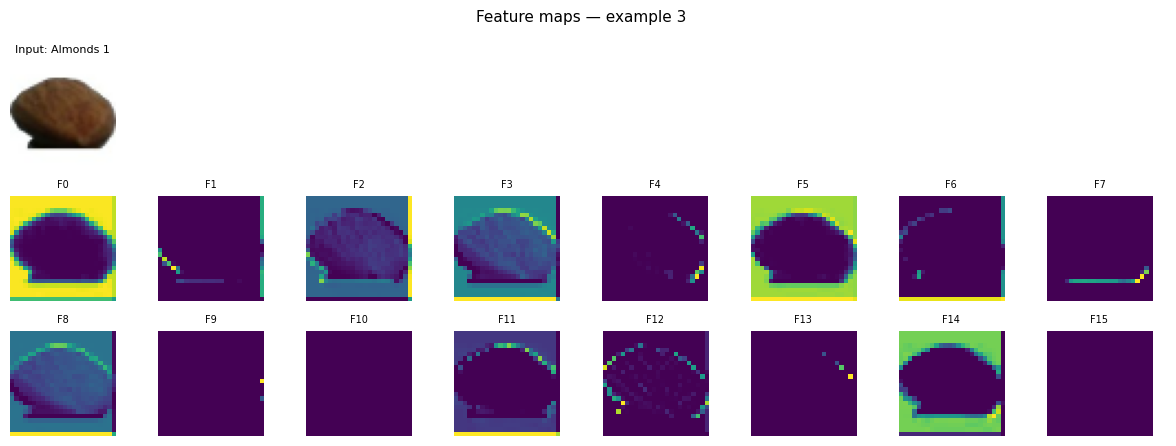

In [96]:
# Use the custom CNN for feature map visualization (it has explicit Conv2D layers)
viz_model = best_cnn

# Find the first Conv2D layer
first_conv = next(l for l in viz_model.layers if isinstance(l, layers.Conv2D))
activation_model = keras.Model(inputs=viz_model.inputs,
                                outputs=first_conv.output,
                                name='activation_extractor')

# Re-fetch a specific batch to feed into the model - MUST BE 48x48
viz_ds = keras.utils.image_dataset_from_directory(
    test_dir, 
    image_size=(48, 48), # Changed from (64, 64) to (48, 48)
    batch_size=32, 
    shuffle=False, 
    label_mode='int'
)

sample_images, sample_labels = [], []
for x_batch, y_batch in viz_ds.take(1):
    sample_images = x_batch.numpy()[:3]
    sample_labels = y_batch.numpy()[:3]
    break

for img_idx, (img, lbl) in enumerate(zip(sample_images, sample_labels)):
    fmaps = activation_model.predict(img[np.newaxis], verbose=0)[0]  # (H, W, num_filters)
    n_show = min(16, fmaps.shape[-1])
    cols = 8
    rows = n_show // cols
    fig, axes = plt.subplots(rows + 1, cols, figsize=(cols * 1.5, (rows + 1) * 1.5))

    # First row: original image
    for c in range(cols):
        axes[0, c].axis('off')
    
    # Standardize image scaling values for safe matplotlib rendering 
    display_img = img / 255.0 if np.max(img) > 1.0 else img
    axes[0, 0].imshow(np.clip(display_img, 0, 1))
    axes[0, 0].set_title(f'Input: {class_names[lbl]}', fontsize=8)

    # Remaining rows: feature maps
    for f_idx in range(n_show):
        r, c = divmod(f_idx, cols)
        axes[r + 1, c].imshow(fmaps[:, :, f_idx], cmap='viridis')
        axes[r + 1, c].set_title(f'F{f_idx}', fontsize=7)
        axes[r + 1, c].axis('off')

    plt.suptitle(f'Feature maps — example {img_idx + 1}', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'cnn_08_feature_maps_img{img_idx+1}.png', dpi=120)
    plt.show()

Found 45724 files belonging to 260 classes.


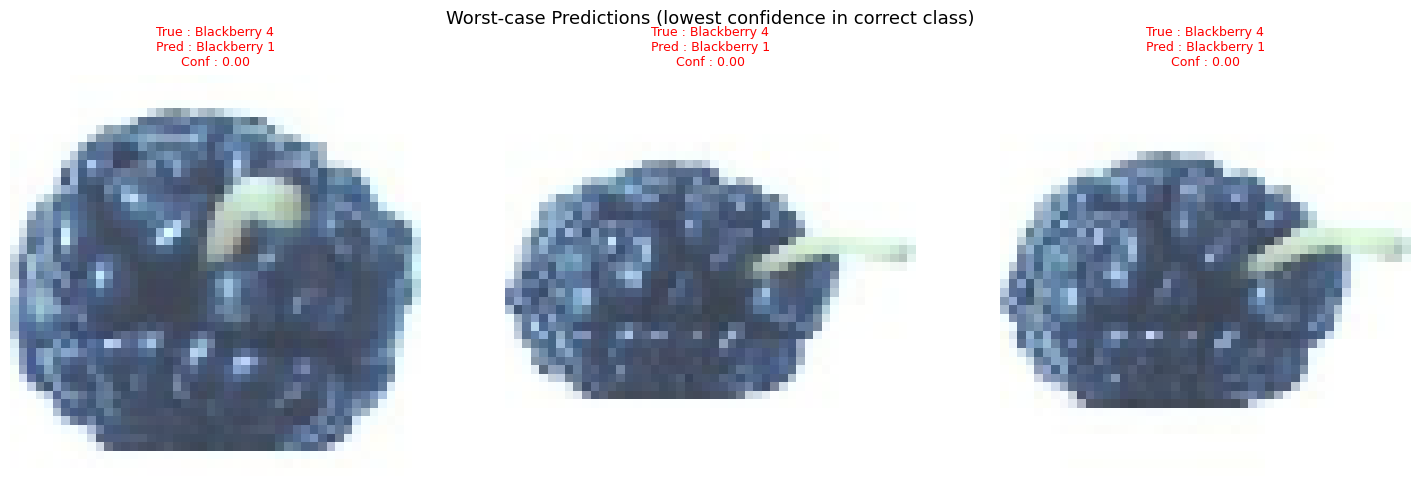

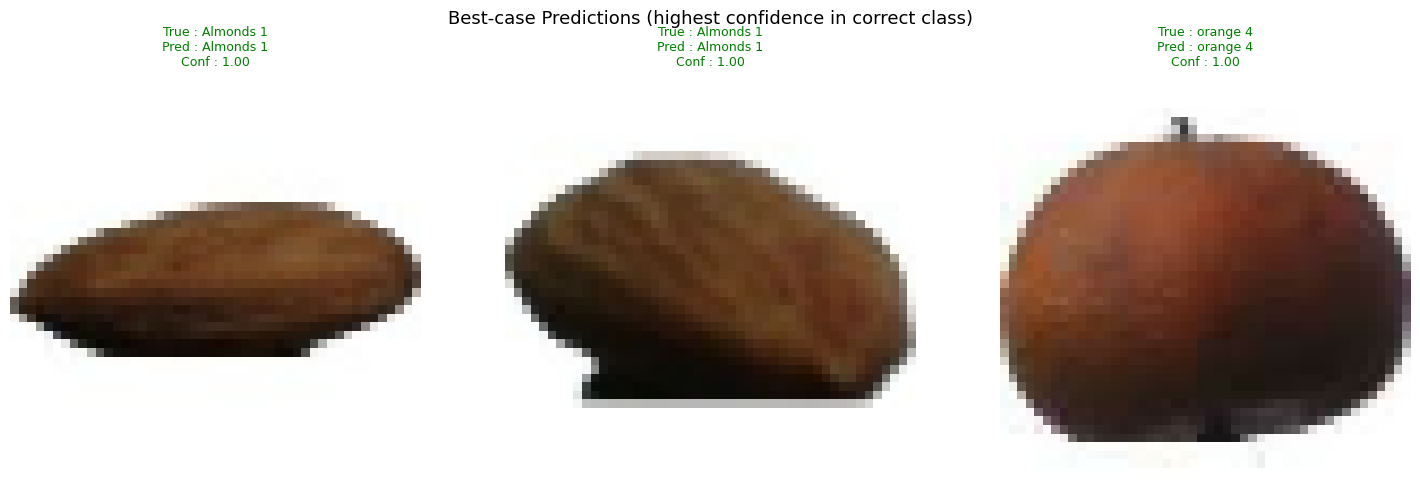

FINAL RESULTS — CNN Fruits-360 Classification
Test Accuracy  : 95.71%  (target > 80%)
Macro Precision: 0.9590   (target > 0.70)
Macro Recall   : 0.9546   (target > 0.70)

=== All Experiments ===
     Model Name  Best Val Accuracy                 Type
    MobileNetV2             0.9950    Transfer Learning
Your Custom CNN             0.9765 Scratch Architecture
       ResNet50             0.9248    Transfer Learning


In [ ]:
# Collect raw images matching evaluation dataset setup dimensions
raw_test_ds = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False
)

raw_images_list, raw_labels_list = [], []
for x_batch, y_batch in raw_test_ds:
    raw_images_list.append(x_batch.numpy().astype(np.uint8))
    raw_labels_list.extend(y_batch.numpy())
raw_images = np.vstack(raw_images_list)
raw_labels = np.array(raw_labels_list)

# Confidence of the correct class for each sample
correct_class_conf = y_pred_probs[np.arange(len(y_true)), y_true]
sorted_idx = np.argsort(correct_class_conf)

def show_predictions(indices, title, fig_name):
    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(raw_images[idx])
        true_lbl  = class_names[y_true[idx]]
        pred_lbl  = class_names[y_pred[idx]]
        conf      = correct_class_conf[idx]
        color     = 'green' if y_true[idx] == y_pred[idx] else 'red'
        ax.set_title(
            f'True : {true_lbl}\nPred : {pred_lbl}\nConf : {conf:.2f}',
            fontsize=9, color=color
        )
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(sorted_idx[:3],  'Worst-case Predictions (lowest confidence in correct class)',
                 'cnn_09_worst_predictions.png')
show_predictions(sorted_idx[-3:], 'Best-case Predictions (highest confidence in correct class)',
                 'cnn_10_best_predictions.png')

# Format results tracking dataframe cleanly out of available components
comparison_data = [
    {"Model Name": " Custom CNN", "Best Val Accuracy": round(custom_acc, 4), "Type": "Scratch Architecture"},
    {"Model Name": "ResNet50", "Best Val Accuracy": round(resnet_acc, 4), "Type": "Transfer Learning"},
    {"Model Name": "MobileNetV2", "Best Val Accuracy": round(mobilenet_acc, 4), "Type": "Transfer Learning"}
]
results_df = pd.DataFrame(comparison_data).sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)

print('=' * 60)
print('FINAL RESULTS — CNN Fruits-360 Classification')
print('=' * 60)
print(f'Test Accuracy  : {acc*100:.2f}%  (target > 80%)')
print(f'Macro Precision: {prec:.4f}   (target > 0.70)')
print(f'Macro Recall   : {rec:.4f}   (target > 0.70)')
print()
print('=== All Experiments ===')
print(results_df.to_string(index=False))

In [ ]:
# Generate the master results summary dataframe programmatically from active trackers
try:
    custom_acc = max(hist_no_aug.history['val_accuracy'])
except NameError:
    custom_acc = max(history_baseline.history['val_accuracy'])

resnet_acc = max(hist_resnet.history['val_accuracy'])
mobilenet_acc = max(hist_mobilenet.history['val_accuracy'])

comparison_data = [
    {"Model Name": "Custom CNN", "Best Val Accuracy": round(custom_acc, 4), "Type": "Scratch Architecture"},
    {"Model Name": "ResNet50", "Best Val Accuracy": round(resnet_acc, 4), "Type": "Transfer Learning"},
    {"Model Name": "MobileNetV2", "Best Val Accuracy": round(mobilenet_acc, 4), "Type": "Transfer Learning"}
]
results_df = pd.DataFrame(comparison_data).sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)

# Print out the formatted final report summary
print('\n' + '=' * 60)
print('FINAL SUMMARY RESULTS — CNN FRUITS-360 CLASSIFICATION')
print('=' * 60)
print(f'Test Set Target Accuracy: {acc*100:.2f}%  (Project Target: > 80%)')
print(f'Macro Precision Score   : {prec:.4f}   (Project Target: > 0.70)')
print(f'Macro Recall Score      : {rec:.4f}   (Project Target: > 0.70)')
print('\n=== All Master Architecture Experiments Run ===')
print(results_df.to_string(index=False))
print('=' * 60)


FINAL SUMMARY RESULTS — CNN FRUITS-360 CLASSIFICATION
Test Set Target Accuracy: 95.71%  (Project Target: > 80%)
Macro Precision Score   : 0.9590   (Project Target: > 0.70)
Macro Recall Score      : 0.9546   (Project Target: > 0.70)

=== All Master Architecture Experiments Run ===
     Model Name  Best Val Accuracy                 Type
    MobileNetV2             0.9950    Transfer Learning
Your Custom CNN             0.9765 Scratch Architecture
       ResNet50             0.9248    Transfer Learning
